# MSD analysis

In this notebook, we analyze the Mean Squared Displacement (MSD) of the cellular system. The MSD  quantifies the average spatial extent explored by the cells over a given time interval $t$.

By evaluating how the MSD scales with time, typically expressed as $\text{MSD}(t) \propto t^\alpha$, we can extract the local scaling exponent $\alpha(t)$ to identify the distinct macroscopic dynamic regimes.

## Importing libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path
import os

## MSD evolution

### Creation of useful functions

In [2]:
def load_global_msd(number_cells, density_list, base_path="data", results_path="results", force_recompute=False):
    """
    Loads global MSD data. If a summarized CSV exists in results, it loads that directly.
    Otherwise, it processes the raw .dat files, calculates the means, saves the summary,
    and returns the dictionary.
    """
    num_cells_folder = f"N={number_cells:_}"
    
    # Define and create results directory
    out_dir = Path(f"{results_path}/{num_cells_folder}/msd")
    out_dir.mkdir(parents=True, exist_ok=True)
    
    summary_file = out_dir / f"global_msd_summary_N={number_cells}.csv"
    
    # Try to load resume
    if summary_file.exists() and not force_recompute:
        print(f"Loading cached summary from {summary_file}...")
        df_all = pd.read_csv(summary_file)
        
        mean_msd_data = {}
        # Rebuild the dictionary grouping by density
        for dens, grp in df_all.groupby("density"):
            mean_msd_data[dens] = grp.set_index("step").drop(columns=["density"])
            
        print(f"Global data loaded from cache for N={number_cells} and {len(mean_msd_data)} densities.")
        return mean_msd_data

    # If it doesn't exit or we forced it, we read data
    print("Reading raw files from data folder (this may take a while)...")
    mean_msd_data = {}
    all_means_for_saving = []

    for dens in density_list:
        dens_str = f"{dens:.3f}".replace(".", "_")
        folder_path = Path(f"{base_path}/{num_cells_folder}/{dens_str}/dat_msd/")
        
        if not folder_path.exists():
            continue
            
        # Take files corresponding to msd
        files = list(folder_path.glob("msd_series_density=*.dat"))
        
        dfs = []
        for file in files:
            dfs.append(pd.read_csv(file))
        
        # Average
        if dfs:
            all_data = pd.concat(dfs)
            mean_df = all_data.groupby("step").mean()
            mean_msd_data[dens] = mean_df
            
            # Prepare a copy
            df_to_save = mean_df.copy()
            df_to_save["density"] = dens
            df_to_save = df_to_save.reset_index()
            all_means_for_saving.append(df_to_save)
            
    # Save for the next time
    if all_means_for_saving:
        df_final_summary = pd.concat(all_means_for_saving, ignore_index=True)
        df_final_summary.to_csv(summary_file, index=False)
        print(f"Summary saved successfully in: {summary_file}")
        
    print(f"Global data processed for N={number_cells} and {len(mean_msd_data)} densities.")
    return mean_msd_data

In [3]:
def plot_msd_and_alpha(mean_data, densities, number_cells, file_suffix=""):
    """
    Plots the global MSD and its local logarithmic derivative alpha(t) 
    to properly identify regimes.
    
    Parameters:
    -----------
    mean_data : dict
        Dictionary with the averaged MSD data.
    densities : list
        List of densities to plot.
    number_cells : float
        Number of cells in the simulation.
    file_suffix : str, optional
        String to append to the end of the filename.
        If empty, it saves as 'msd_alpha.png'.
    """
    num_cells_folder = f"N={number_cells:_}"
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]})

    # Color of the curves    
    norm = mcolors.Normalize(vmin=min(densities), vmax=max(densities))
    cmap = cm.viridis
    
    # Variables to track the global min and max time for the reference lines
    global_min_t = np.inf
    global_max_t = 0
    
    for dens in densities:
        if dens in mean_data:
            df = mean_data[dens]
            steps = df.index.values
            valid = steps > 0 
            
            t = steps[valid]
            if len(t) > 0:
                global_min_t = min(global_min_t, t.min())
                global_max_t = max(global_max_t, t.max())
                
            msd = df["msd_global"].values[valid]
            color = cmap(norm(dens))
            
            # Plot MSD (Top Panel)
            ax1.plot(t, msd, color=color, lw=2, alpha=0.9)
            
            # Calculate and plot alpha(t) (Bottom Panel)
            log_t = np.log(t)
            log_msd = np.log(msd)
            
            # Calculate gradient (local slope = alpha)
            alpha = np.gradient(log_msd, log_t)
            
            # Smooth the alpha curve to reduce numerical noise
            window_size = 5
            if len(alpha) > window_size:
                alpha_smooth = np.convolve(alpha, np.ones(window_size)/window_size, mode='valid')
                t_smooth = t[window_size//2 : -window_size//2 + 1]
            else:
                alpha_smooth = alpha
                t_smooth = t
                
            ax2.plot(t_smooth, alpha_smooth, color=color, lw=2, alpha=0.8)

    # Formatting Top Panel (MSD)
    ax1.axvline(x=200, color='gray', linestyle=':', lw=2, alpha=0.8)
    ax1.text(250, 1e1, 'Phenotype Activation', color='gray', fontsize=11)
    
    # Reference lines spanning from min valid time to max time
    if global_min_t < np.inf:
        ref_steps = np.array([global_min_t, global_max_t])
        
        # Diffusive line (~t^1). Forced to start exactly at y = 100
        prefactor_diffusive = 100.0 / global_min_t
        ax1.plot(ref_steps, prefactor_diffusive * ref_steps, 'r--', lw=2, label=r'Diffusive ($\sim t^1$)')
        
        # Ballistic line (~t^2). Forced to start at y = 10 
        prefactor_ballistic = 10.0 / (global_min_t**2)
        ax1.plot(ref_steps, prefactor_ballistic * ref_steps**2, 'k--', lw=2, label=r'Ballistic ($\sim t^2$)')
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_ylabel('Global MSD', fontsize=14)
    ax1.set_title('Time Evolution of Global MSD', fontsize=16)
    ax1.legend(fontsize=12, loc='upper left')
    ax1.grid(True, which="both", ls="--", alpha=0.3)
    
    # Add Colorbar to ax1
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax1)
    cbar.set_label(r'Density ($\rho$)', fontsize=14)

    # Formatting Bottom Panel (Alpha)
    ax2.axvline(x=200, color='gray', linestyle=':', lw=2, alpha=0.8)
    
    # Theoretical reference lines for Alpha
    ax2.axhline(y=1.0, color='red', linestyle='--', lw=1.5, alpha=0.8)
    ax2.axhline(y=2.0, color='black', linestyle='--', lw=1.5, alpha=0.8)
    
    ax2.set_xlabel('Time (Step)', fontsize=14)
    ax2.set_ylabel(r'Exponente $\alpha(t)$', fontsize=14)
    
    ax2.set_ylim(0, 5) 
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    
    plt.tight_layout()
    
    # Save images
    save_dir = f"graphs/{num_cells_folder}/msd"
    os.makedirs(save_dir, exist_ok=True)
    
    if file_suffix:
        save_path = os.path.join(save_dir, f"msd_alpha_{file_suffix}.png")
    else:
        save_path = os.path.join(save_dir, "msd_alpha.png")
        
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Graphs saved in: {save_path}")
    
    plt.show()

In [4]:
def plot_msd_over_2t_and_alpha(mean_data, densities, number_cells, file_suffix=""):
    """
    Plots MSD/(2t) and the local logarithmic derivative alpha(t) of the raw MSD
    to visualize the effective diffusion coefficient transition directly.
    
    Parameters:
    -----------
    mean_data : dict
        Dictionary with the averaged MSD data.
    densities : list
        List of densities to plot.
    number_cells : float
        Number of cells in the simulation.
    file_suffix : str, optional
        String to append to the end of the filename.
    """
    num_cells_folder = f"N={number_cells:_}"
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]})

    # Color of the curves    
    norm = mcolors.Normalize(vmin=min(densities), vmax=max(densities))
    cmap = cm.viridis
    
    # Variables to track the global min and max time for the reference lines
    global_min_t = np.inf
    global_max_t = 0
    
    for dens in densities:
        if dens in mean_data:
            df = mean_data[dens]
            steps = df.index.values
            valid = steps > 0 
            
            t = steps[valid]
            if len(t) > 0:
                global_min_t = min(global_min_t, t.min())
                global_max_t = max(global_max_t, t.max())
                
            msd = df["msd_global"].values[valid]
            
            # --- NUEVA MÉTRICA: D_eff(t) = MSD / 4t ---
            d_eff = msd / (4.0 * t)
            
            color = cmap(norm(dens))
            
            # Plot D_eff(t) (Top Panel)
            ax1.plot(t, d_eff, color=color, lw=2, alpha=0.9)
            
            # Calculate and plot alpha(t) from the ORIGINAL MSD (Bottom Panel)
            # Keeping the raw MSD for log derivation preserves the classic 1 (diff) and 2 (ballistic) meaning.
            log_t = np.log(t)
            log_msd = np.log(msd)
            
            # Calculate gradient (local slope = alpha)
            alpha = np.gradient(log_msd, log_t)
            
            # Smooth the alpha curve to reduce numerical noise
            window_size = 5
            if len(alpha) > window_size:
                alpha_smooth = np.convolve(alpha, np.ones(window_size)/window_size, mode='valid')
                t_smooth = t[window_size//2 : -window_size//2 + 1]
            else:
                alpha_smooth = alpha
                t_smooth = t
                
            ax2.plot(t_smooth, alpha_smooth, color=color, lw=2, alpha=0.8)

    # Formatting Top Panel (MSD / 2t)
    ax1.axvline(x=200, color='gray', linestyle=':', lw=2, alpha=0.8)
    # Formatting Top Panel (D_eff)
    ax1.axvline(x=200, color='gray', linestyle=':', lw=2, alpha=0.8)
    
    # Usamos transform para que el texto quede siempre al 5% del eje Y, independientemente de la escala real
    ax1.text(250, 0.05, 'Phenotype Activation', color='gray', fontsize=11, transform=ax1.get_xaxis_transform())
    
    # Reference lines spanning from min valid time to max time
    if global_min_t < np.inf:
        ref_steps = np.array([global_min_t, global_max_t])
        
        # Diffusive line: MSD ~ t^1 => D_eff ~ t^0 (CONSTANT horizontal line)
        anchor_diffusive = 100.0 / (4.0 * global_min_t)
        ax1.plot(ref_steps, [anchor_diffusive, anchor_diffusive], 'r--', lw=2, label=r'Diffusive ($\sim t^0$)')
        
        # Ballistic line: MSD ~ t^2 => D_eff ~ t^1 (Linear line in log-log)
        prefactor_ballistic = 10.0 / (4.0 * (global_min_t**2))
        ax1.plot(ref_steps, prefactor_ballistic * ref_steps, 'k--', lw=2, label=r'Ballistic ($\sim t^1$)')
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_ylabel(r'$D_{eff}(t) = \frac{MSD}{4t}$', fontsize=14)
    ax1.set_title(r'Time Evolution of Effective Diffusion', fontsize=16)
    ax1.legend(fontsize=12, loc='upper left')
    ax1.grid(True, which="both", ls="--", alpha=0.3)
    
    # Add Colorbar to ax1
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax1)
    cbar.set_label(r'Density ($\rho$)', fontsize=14)

    # Formatting Bottom Panel (Alpha)
    ax2.axvline(x=200, color='gray', linestyle=':', lw=2, alpha=0.8)
    
    # Theoretical reference lines for Alpha
    ax2.axhline(y=1.0, color='red', linestyle='--', lw=1.5, alpha=0.8)
    ax2.axhline(y=2.0, color='black', linestyle='--', lw=1.5, alpha=0.8)
    
    ax2.set_xlabel('Time (Step)', fontsize=14)
    ax2.set_ylabel(r'Exponente $\alpha(t)$', fontsize=14)
    
    ax2.set_ylim(0, 5) 
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    
    plt.tight_layout()
    
    # Save images
    save_dir = f"graphs/{num_cells_folder}/msd"
    os.makedirs(save_dir, exist_ok=True)
    
    if file_suffix:
        save_path = os.path.join(save_dir, f"deff_alpha_{file_suffix}.png")
    else:
        save_path = os.path.join(save_dir, "deff_alpha.png")
        
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Graphs saved in: {save_path}")
    
    plt.show()

### Plot

In [5]:
# Define parameters
number_cells = 500
density_list = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.71, 0.72, 0.73, 
                0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 
                0.85, 0.86, 0.87, 0.88, 0.89, 0.9]

# Load data
mean_msd = load_global_msd(number_cells, density_list)

Loading cached summary from results/N=500/msd/global_msd_summary_N=500.csv...
Global data loaded from cache for N=500 and 29 densities.


Graphs saved in: graphs/N=500/msd/msd_alpha.png


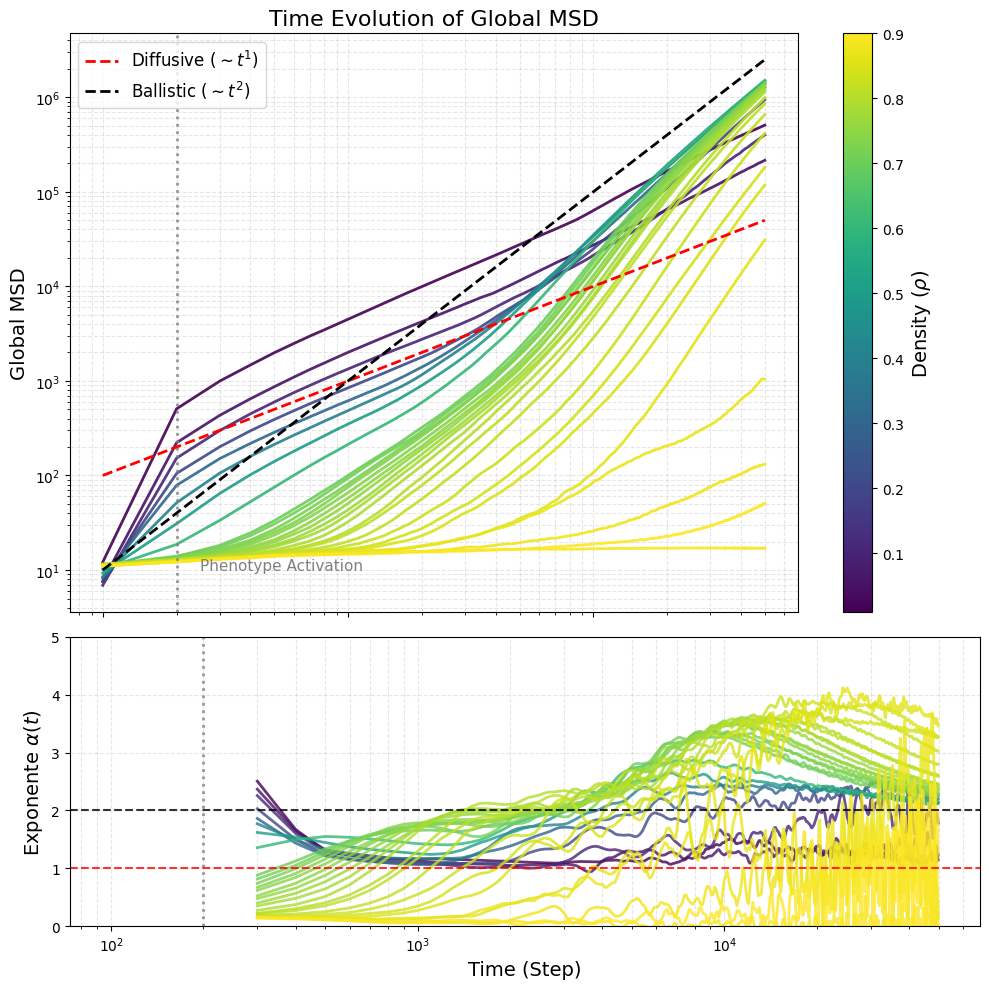

In [6]:
# Plot
plot_msd_and_alpha(mean_msd, density_list, number_cells)

We can see less densities in order to visualize better.

Graphs saved in: graphs/N=500/msd/msd_alpha_samples.png


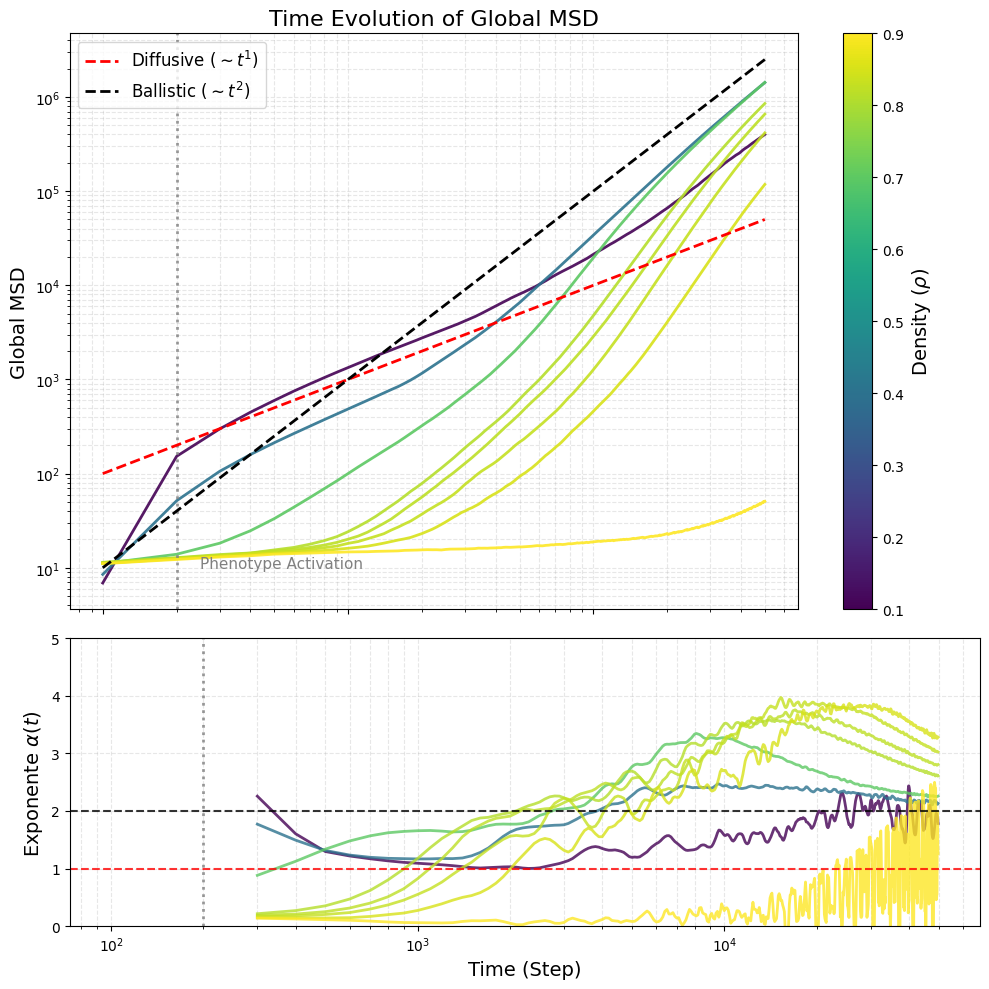

In [7]:
density_list_samples = [0.1, 0.4, 0.7, 0.81, 0.82, 0.83, 0.85, 0.9]
# Plot
plot_msd_and_alpha(mean_msd, density_list_samples, number_cells, "samples")

And now, let's see the Efective Difussion Coeficient:

Graphs saved in: graphs/N=500/msd/deff_alpha.png


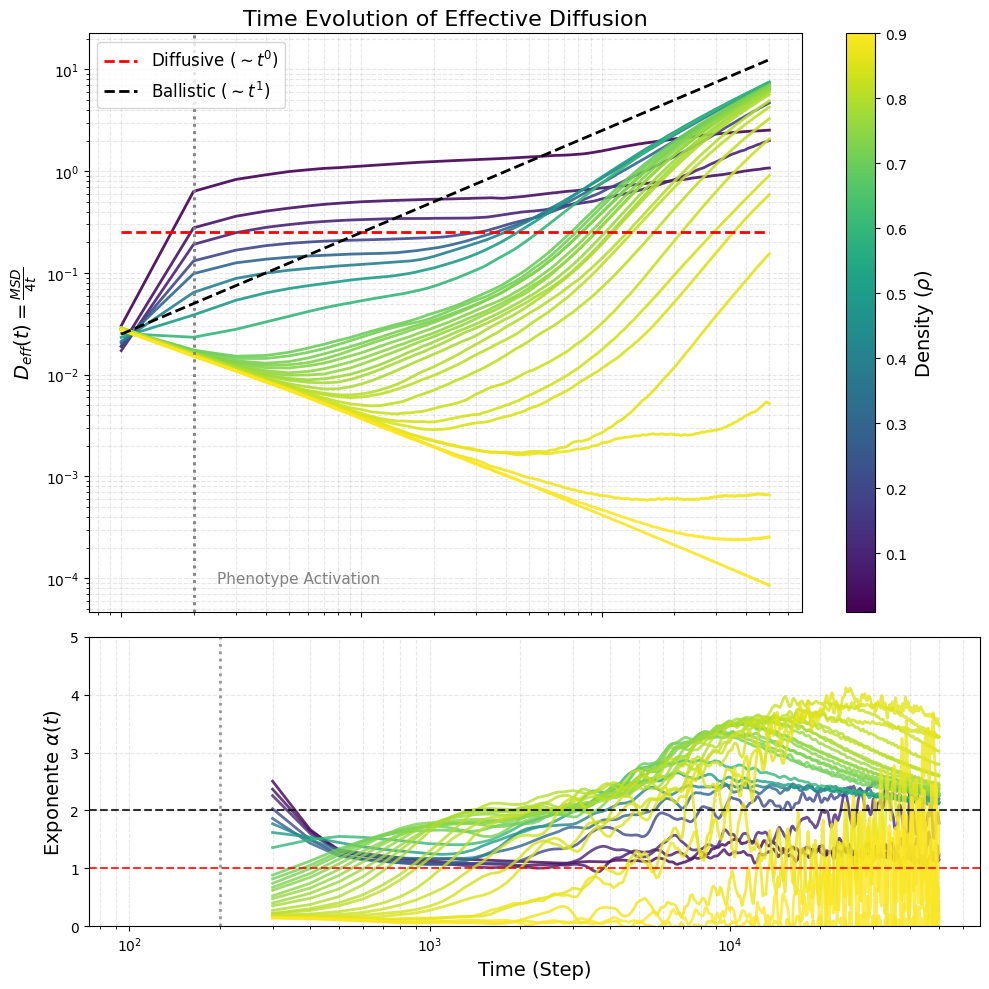

In [8]:
# Plot
plot_msd_over_2t_and_alpha(mean_msd, density_list, number_cells)

And again, we plot less densities:

Graphs saved in: graphs/N=500/msd/deff_alpha_samples.png


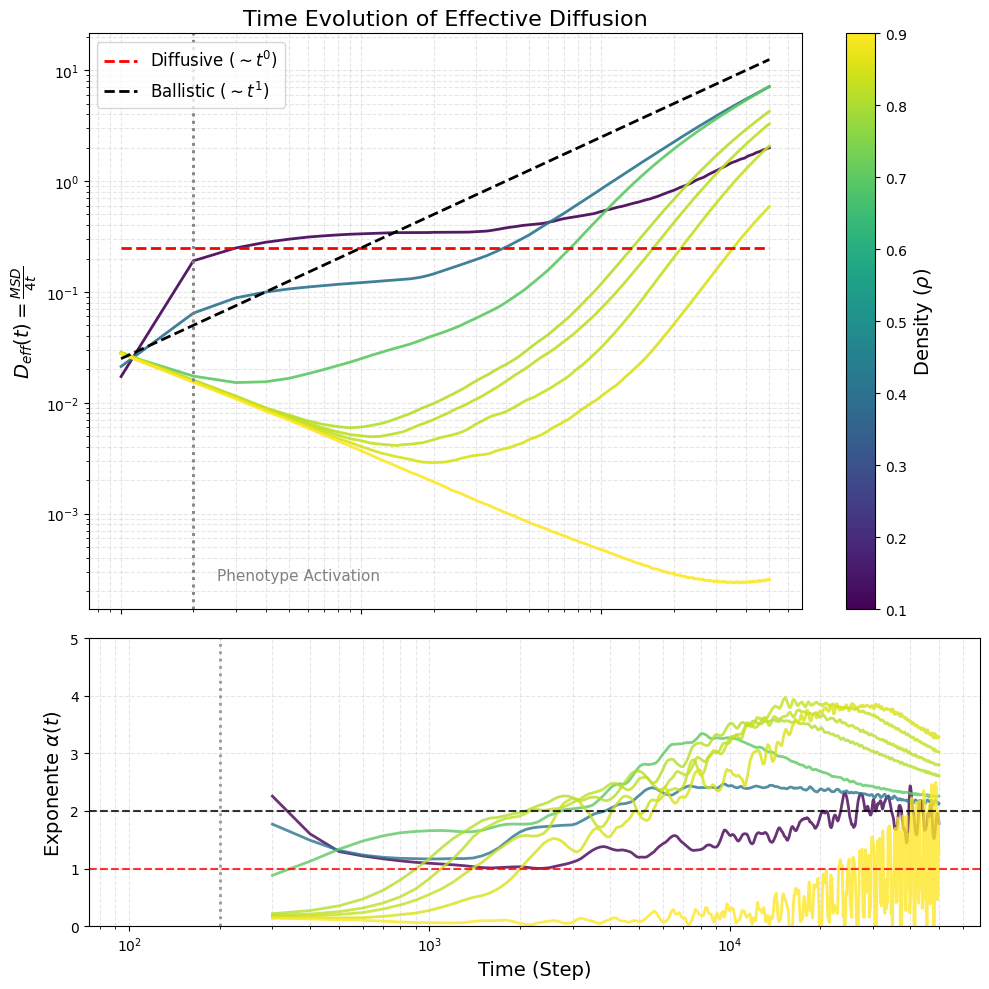

In [9]:
# Plot
plot_msd_over_2t_and_alpha(mean_msd, density_list_samples, number_cells, "samples")